# Employee attrition: exploratory data analysis

All inspection for this project lives in this notebook. Load the CSV from `data/raw`, then work through the cells below.

In [1]:
import sys
print(sys.executable)
print(sys.version)

c:\Python313\python.exe
3.13.3 (tags/v3.13.3:6280bb5, Apr  8 2025, 14:47:33) [MSC v.1943 64 bit (AMD64)]


In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df.shape

(1470, 35)

In [4]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [6]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## Step 4: First inspection before modeling

Work through the checks below. Use them to see class balance, data quality, types, and which columns are informative.

In [7]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [8]:
df["Attrition"].value_counts(normalize=True)

Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64

In [9]:
df.isnull().sum().sort_values(ascending=False)

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.dtypes

Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesL

In [12]:
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    print(col, df[col].nunique())

Attrition 2
BusinessTravel 3
Department 3
EducationField 6
Gender 2
JobRole 9
MaritalStatus 3
Over18 1
OverTime 2


C:\Users\HP\AppData\Local\Temp\ipykernel_19716\2717166534.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


In [13]:
for name in ["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"]:
    if name in df.columns:
        print(name, "nunique:", df[name].nunique())
        print("  sample values:", df[name].unique()[:8])

EmployeeCount nunique: 1
  sample values: [1]
Over18 nunique: 1
  sample values: <StringArray>
['Y']
Length: 1, dtype: str
StandardHours nunique: 1
  sample values: [80]
EmployeeNumber nunique: 1470
  sample values: [ 1  2  4  5  7  8 10 11]


## Initial findings

- Dataset has 1470 rows and 35 columns (confirm with `df.shape`).
- Target column name: **Attrition** (Yes / No).
- Attrition is **imbalanced**: "No" is the majority class; "Yes" is much smaller. Use the normalized `value_counts` above for exact shares.
- **No** missing values in this file: `isnull` sums should all be zero.
- **No** duplicate rows: `df.duplicated().sum()` should be 0.
- Mix of numeric columns (scores, tenure, income, counts) and object columns (categories such as Department, JobRole, OverTime). `df.info` and `df.dtypes` spell out which is which.
- **EmployeeCount**, **Over18**, and **StandardHours** are constant (one unique value each), so they do not help a model.
- **EmployeeNumber** is unique per row (ID-like); drop or exclude it for modeling.
- Initial impression: clean tabular HR data suited to classification after dropping non-informative or ID columns and encoding categoricals; plan for imbalance when you train (metrics, resampling, or class weights).

## Step 5: Clean obvious useless columns and prepare features/target

No full preprocessing yet. Remove identifiers, constant columns, and fields with no predictive meaning. Then define feature matrix `X` and target `y`.

Inspect uniqueness across columns first, then drop the usual suspects for this dataset.

In [14]:
df.nunique().sort_values()

EmployeeCount                  1
Over18                         1
StandardHours                  1
Attrition                      2
OverTime                       2
PerformanceRating              2
Gender                         2
BusinessTravel                 3
Department                     3
MaritalStatus                  3
RelationshipSatisfaction       4
StockOptionLevel               4
JobSatisfaction                4
EnvironmentSatisfaction        4
JobInvolvement                 4
WorkLifeBalance                4
Education                      5
JobLevel                       5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
Age                           43
HourlyRate

In [15]:
drop_cols = ["EmployeeNumber", "EmployeeCount", "Over18", "StandardHours"]
df = df.drop(columns=drop_cols, errors="ignore")

In [16]:
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

In [17]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [18]:
X.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,...,3,1,0,8,0,1,6,4,0,5
1,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,...,4,4,1,10,3,3,10,7,1,7
2,37,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,...,3,2,0,7,3,3,0,0,0,0
3,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,...,3,3,0,8,3,3,8,7,3,0
4,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,...,3,4,1,6,3,3,2,2,2,2


In [19]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64

### Why this matters

The table is now framed as a standard supervised learning problem: `X` holds inputs, `y` is a numeric binary target, and obvious non-predictive columns are gone. Encoding, scaling, and train/test splitting can follow in a later step.

## Step 6: Train-test split

You already dropped obvious useless columns, mapped **Attrition** to 0/1, and built `X` and `y`. Next, split into training and test sets.

### Why we split

The model should learn from one part of the data and be scored on **held-out** rows. If you train and evaluate on the same rows, metrics look better than they are in real use.

### Why this step comes now

Split **before** scaling, encoding, imputation, or fitting the model. If you preprocess the full dataset first, statistics or patterns from the test portion can influence training. That is a form of **data leakage**.

### What to use

Use `train_test_split` with **`stratify=y`** because attrition is imbalanced. Stratification keeps similar class proportions in train and test (roughly 83.9% class 0 and 16.1% class 1 in the full data). Without it, the test set could end up with a very different balance.

### Parameters

- **`test_size=0.2`**: about 80% train, 20% test (a common default).
- **`random_state=42`**: fixes the random split so reruns of the notebook match.
- **`stratify=y`**: preserves class ratios in both `y_train` and `y_test`.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

In [23]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1176, 30)
X_test shape: (294, 30)
y_train shape: (1176,)
y_test shape: (294,)


In [24]:
print("y_train distribution:")
print(y_train.value_counts(normalize=True))

print("\ny_test distribution:")
print(y_test.value_counts(normalize=True))

y_train distribution:
Attrition
0    0.838435
1    0.161565
Name: proportion, dtype: float64

y_test distribution:
Attrition
0    0.840136
1    0.159864
Name: proportion, dtype: float64


In [25]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Number of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))
print("\nNumeric features:", numeric_features)
print("\nCategorical features:", categorical_features)

Number of numeric features: 23
Number of categorical features: 7

Numeric features: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical features: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


C:\Users\HP\AppData\Local\Temp\ipykernel_19716\1519011560.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()


# Next step: build the preprocessing pipeline

You need a pipeline that:

* imputes missing numeric values
* scales numeric values
* imputes missing categorical values
* one-hot encodes categorical values

Even if this dataset has few or no missing values, it is still good practice to build the pipeline properly.

---

## Why we do this

Your data has two types of columns:

* **numeric**
* **categorical**

They cannot be treated the same way.

### Numeric columns

Usually need:

* missing value handling
* scaling

### Categorical columns

Usually need:

* missing value handling
* encoding into numbers

ML models cannot directly use text categories like `Sales`, `Travel_Rarely`, or `Married`. We convert them with **OneHotEncoder**.

---

## Why use a pipeline instead of manual preprocessing

A pipeline is:

* cleaner
* reproducible
* safer
* easier to keep leakage-free when you fit on train only
* easier to deploy later

This beats editing the dataframe in many separate cells.

---

# Do this now

## 1. Import required tools

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## 2. Create numeric transformer

### Why

* **median** is a safe default for numeric missing values
* **StandardScaler** helps models like Logistic Regression

In [27]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

## 3. Create categorical transformer

### Why

* **most_frequent** fills missing categorical values
* **OneHotEncoder** turns categories into numeric columns
* **handle_unknown="ignore"** avoids errors when test data has a category not seen in training

In [28]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

## 4. Combine them in one preprocessor

This applies the numeric pipeline to numeric columns and the categorical pipeline to categorical columns (using the lists you built from `X_train`).

In [29]:
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

# What this gives you

You have a preprocessing object you can attach to any model. Later you can wrap it like this:

```python
Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(...)),
])
```

That runs preprocessing then training in one workflow.

---

## Optional quick check

Fit on **train** only, then transform test. The processed feature count will be **larger** than the raw column count because one-hot encoding expands categories. That is expected.

**Note:** Tree models such as Random Forest or XGBoost often do not need scaling the way Logistic Regression does, but this general setup is still fine. A common first baseline is **Logistic Regression**.

In [30]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Processed X_train shape: (1176, 51)
Processed X_test shape: (294, 51)


You started with about **30** input columns in `X`, and after one-hot encoding the categorical columns the transformed matrix has about **51** columns. That is normal.

# Next step: train a baseline model

Start with **Logistic Regression**.

* Standard baseline for binary classification
* Fits scaled numeric inputs well
* Interpretable coefficients
* Solid benchmark before more complex models

---

## Step 8: Build baseline Logistic Regression pipeline

Combine preprocessing and the estimator in **one** `Pipeline` so you fit and predict in one object.

### Imports

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

### Create the model pipeline

### Why `max_iter=1000`?

Logistic Regression can fail to converge with the default iteration cap. **1000** is a common safe setting.

In [32]:
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(random_state=42, max_iter=1000)),
])

### Train the model

In [33]:
log_reg_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

### Make predictions

* **`y_pred`**: hard class labels (0 or 1)
* **`y_proba`**: predicted probability of attrition (class 1), needed for **ROC-AUC**

In [34]:
y_pred = log_reg_pipeline.predict(X_test)
y_proba = log_reg_pipeline.predict_proba(X_test)[:, 1]

### Evaluate the model

In [35]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8605442176870748
ROC-AUC: 0.8115255405289

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294


Confusion Matrix:

[[237  10]
 [ 31  16]]


### Why this matters

At this stage you want:

* How strong is a simple baseline?
* Does it flag any true attrition cases?
* Is it better than always predicting the majority class?

Because the problem is **imbalanced**, do **not** judge the model on accuracy alone. Also look at **recall for class 1**, **F1 for class 1**, and **ROC-AUC**. Class **1** is attrition, the costly class to miss.

---

### What the confusion matrix means

With labels 0 and 1, `confusion_matrix(y_test, y_pred)` is laid out as:

```text
[[TN  FP]
 [FN  TP]]
```

* **TN**: predicted stayed, actually stayed
* **FP**: predicted attrition, actually stayed
* **FN**: predicted stayed, actually left (often costly for HR)
* **TP**: predicted attrition, actually left

For attrition, **FN** is especially important: the model missed someone who really left.

## Reading the baseline results

This is a decent baseline, but it highlights the main weakness: the model is **strong on employees who stay** and **weak on catching employees who leave**.

### Accuracy = 0.86

Looks good at first, but with ~84% class 0, accuracy is easy to inflate. A model can score well while still missing many attrition cases.

### ROC-AUC = 0.81

A solid signal: the model can rank leavers vs non-leavers reasonably well across thresholds. It is learning useful structure.

### Class 1 performance (attrition)

* **Precision ~ 0.62** – when it predicts attrition, it is right about 62% of the time
* **Recall ~ 0.34** – it only catches about 34% of true attrition cases
* **F1 ~ 0.44** – combined score reflects that low recall

Low recall means many leavers are missed.

### Confusion matrix (example from this run)

```text
[[237  10]
 [ 31  16]]
```

* **237** true negatives: predicted stay, stayed
* **10** false positives: predicted attrition, stayed
* **31** false negatives: predicted stay, but they left
* **16** true positives: predicted attrition, left

The main pain point is **31 missed leavers**, which drives poor recall for class 1.

---

## Conclusion on this baseline

* **Good as a benchmark**
* **Not strong enough on the attrition class yet**
* **Imbalance is visible** in the metrics

That is what you want from a first baseline: a clear direction for the next experiment.

---

# Next step: Logistic Regression with class balancing

Try **`class_weight="balanced"`** next.

## Why

Sklearn reweights the loss so errors on the minority class count more. The default model leans toward the majority class; balancing pushes it to flag more potential leavers.

You often see:

* **Higher recall for class 1**
* **Accuracy may drop**
* **Precision may drop**
* **Better tradeoff** for HR if missing leavers is costly

That tradeoff is normal.

## Balanced model: steps to run

### 1. Build the balanced pipeline

In [36]:
log_reg_balanced_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    (
        "model",
        LogisticRegression(
            random_state=42,
            max_iter=1000,
            class_weight="balanced",
        ),
    ),
])

### 2. Train

In [37]:
log_reg_balanced_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

### 3. Predict

In [38]:
y_pred_bal = log_reg_balanced_pipeline.predict(X_test)
y_proba_bal = log_reg_balanced_pipeline.predict_proba(X_test)[:, 1]

### 4. Evaluate

In [39]:
print("Accuracy:", accuracy_score(y_test, y_pred_bal))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_bal))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_bal))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_bal))

Accuracy: 0.7517006802721088
ROC-AUC: 0.8031699543457662

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.35      0.64      0.45        47

    accuracy                           0.75       294
   macro avg       0.63      0.71      0.65       294
weighted avg       0.83      0.75      0.78       294


Confusion Matrix:

[[191  56]
 [ 17  30]]


## Compare to the default Logistic Regression

Focus on **class 1**: precision, recall, F1, and **false negatives** in the confusion matrix.

Main question: **Did balancing catch more true attrition cases?** That often matters more than a small accuracy change.

## What you should expect

* Recall for attrition often **increases**
* Precision may **decrease**
* Accuracy may **dip slightly**
* F1 for class 1 may **improve**

For HR-style attrition, prioritizing fewer missed leavers is often reasonable. Re-run the cells above and compare the printed metrics to the unbalanced baseline.

## Which model is better?

For an attrition-risk use case:

* **Default Logistic Regression** fits when you care more about **avoiding false alarms** (fewer people wrongly flagged as high risk).
* **Balanced Logistic Regression** fits when you care more about **catching people at risk of leaving**.

For many HR settings the second goal matters more, because **missing likely leavers** is expensive.

Balanced models often **trade precision for recall**. If precision for class 1 is around **0.35**, many flagged employees are **false positives**. Treat that as a signal to keep iterating, not as a final production model.

---

## Story you can tell in the project

* The first baseline looked accurate overall but **under-detected** the minority class.
* **Class balancing** improved detection of attrition substantially.
* That illustrates why **accuracy alone** is misleading on imbalanced HR data.

That line of reasoning is easy for reviewers to follow.

---

# Next step: Random Forest

Train a **tree-based** model and compare it to **both** Logistic Regression runs.

**Random Forest** is a strong next step because it:

* Is a solid default on tabular data
* Captures **non-linear** patterns
* Does not **require** scaling in theory (your pipeline can stay as-is for a fair comparison)
* Exposes **feature importances**
* Is relatively easy to explain

## Do this next

### 1. Import

In [40]:
from sklearn.ensemble import RandomForestClassifier

### 2. Build pipeline

Reuse the same `preprocessor` so comparisons stay aligned.

In [41]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestClassifier(random_state=42, n_estimators=200),
    ),
])

### 3. Train

In [42]:
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

### 4. Predict

In [43]:
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

### 5. Evaluate

In [44]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.8503401360544217
ROC-AUC: 0.8037298647600999

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.98      0.92       247
           1       0.64      0.15      0.24        47

    accuracy                           0.85       294
   macro avg       0.75      0.57      0.58       294
weighted avg       0.82      0.85      0.81       294


Confusion Matrix:

[[243   4]
 [ 40   7]]


### Note on preprocessing with Random Forest

Trees do not need **StandardScaler** the way linear models do. Keeping the **same** preprocessor anyway is fine here because:

* The workflow stays consistent across models
* Side-by-side metrics stay easy to interpret

Later you can split preprocessing (e.g. scaling for linear models only) if you want to optimize each family separately.

---

## Model comparison table

After you run Random Forest, copy the key numbers into this table (from the printed reports above).

| Model                        | Accuracy | ROC-AUC | Precision (class 1) | Recall (class 1) | F1 (class 1) |
| ---------------------------- | -------: | ------: | ------------------: | ---------------: | -----------: |
| Logistic Regression          |          |         |                     |                  |              |
| Logistic Regression Balanced |          |         |                     |                  |              |
| Random Forest                |          |         |                     |                  |              |

Use it in write-ups to show how each approach trades off overall accuracy vs attrition detection.

In [45]:
results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": 0.8605,
        "ROC_AUC": 0.8115,
        "Precision_Class1": 0.62,
        "Recall_Class1": 0.34,
        "F1_Class1": 0.44
    },
    {
        "Model": "Logistic Regression (Balanced)",
        "Accuracy": 0.7517,
        "ROC_AUC": 0.8032,
        "Precision_Class1": 0.35,
        "Recall_Class1": 0.64,
        "F1_Class1": 0.45
    },
    {
        "Model": "Random Forest",
        "Accuracy": 0.8503,
        "ROC_AUC": 0.8037,
        "Precision_Class1": 0.64,
        "Recall_Class1": 0.15,
        "F1_Class1": 0.24
    }
])

results

,Model,Accuracy,ROC_AUC,Precision_Class1,Recall_Class1,F1_Class1
0,Logistic Regression,0.8605,0.8115,0.62,0.34,0.44
1,Logistic Regression (Balanced),0.7517,0.8032,0.35,0.64,0.45
2,Random Forest,0.8503,0.8037,0.64,0.15,0.24


## 3. Threshold tuning (balanced Logistic Regression)

`predict` uses a default cutoff of **0.5** on the positive-class probability. That value is arbitrary. Scan several cutoffs and pick the one that maximizes **F1 for class 1** (attrition), then re-evaluate at that threshold.

### Code (extend `thresholds` if you want a finer search)

In [46]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

y_scores_bal = log_reg_balanced_pipeline.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.91, 0.05)

threshold_results = []

for t in thresholds:
    y_pred_t = (y_scores_bal >= t).astype(int)
    threshold_results.append({
        "threshold": t,
        "precision_1": precision_score(y_test, y_pred_t, zero_division=0),
        "recall_1": recall_score(y_test, y_pred_t, zero_division=0),
        "f1_1": f1_score(y_test, y_pred_t, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df.sort_values(by="f1_1", ascending=False)

,threshold,precision_1,recall_1,f1_1
10,0.60,0.435484,0.574468,0.495413
6,0.40,0.349057,0.787234,0.483660
11,0.65,0.469388,0.489362,0.479167
12,0.70,0.512195,0.446809,0.477273
13,0.75,0.542857,0.404255,0.463415
9,0.55,0.378378,0.595745,0.462810
5,0.35,0.316667,0.808511,0.455090
7,0.45,0.340426,0.680851,0.453901
8,0.50,0.348837,0.638298,0.451128
14,0.80,0.586207,0.361702,0.447368


Use the row with the largest **`f1_1`** as **`best_threshold`**, then score the test set again at that cutoff.

In [47]:
best_threshold = threshold_df.sort_values(by="f1_1", ascending=False).iloc[0]["threshold"]
best_threshold

np.float64(0.6000000000000002)

In [48]:
y_pred_best = (y_scores_bal >= best_threshold).astype(int)

print("Best threshold:", best_threshold)
print(classification_report(y_test, y_pred_best))
print(confusion_matrix(y_test, y_pred_best))

Best threshold: 0.6000000000000002
              precision    recall  f1-score   support

           0       0.91      0.86      0.89       247
           1       0.44      0.57      0.50        47

    accuracy                           0.81       294
   macro avg       0.67      0.72      0.69       294
weighted avg       0.84      0.81      0.82       294

[[212  35]
 [ 20  27]]


## 4. PR curve and ROC curve

Plot **ROC** and **Precision-Recall** curves for the balanced Logistic Regression scores (`y_scores_bal`). They help explain tradeoffs beyond a single threshold and are easy to drop into a report or README.

### Precision-Recall curve

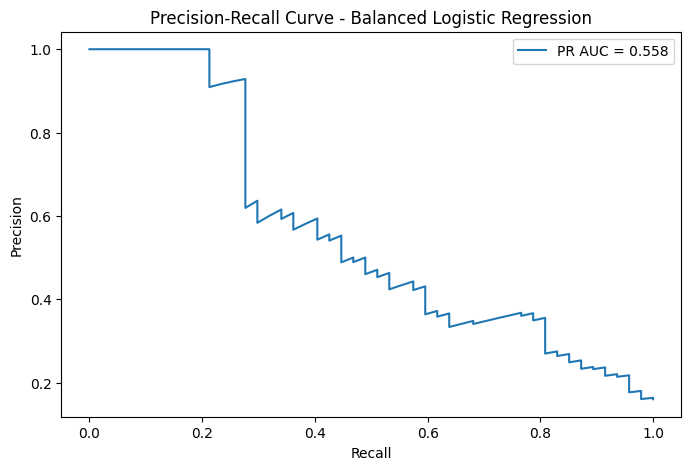

In [49]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve, auc

precision, recall, _ = precision_recall_curve(y_test, y_scores_bal)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Balanced Logistic Regression")
plt.legend()
plt.show()

### ROC curve

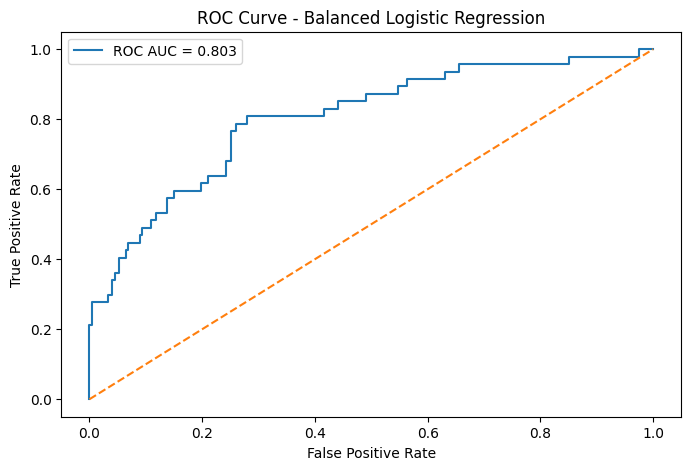

In [50]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_scores_bal)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Balanced Logistic Regression")
plt.legend()
plt.show()

Threshold tuning improved the balanced Logistic Regression model by finding a better precision-recall tradeoff for attrition detection. Raising the decision threshold from 0.50 to 0.60 increased class-1 F1 from 0.45 to 0.50 and reduced false positives substantially, while maintaining useful recall. This showed that threshold selection was a more important lever than accuracy-based comparison alone.

In [51]:
results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Threshold": 0.50,
        "ROC_AUC": 0.8115,
        "PR_AUC": None,
        "Precision_1": 0.62,
        "Recall_1": 0.34,
        "F1_1": 0.44
    },
    {
        "Model": "Logistic Regression Balanced",
        "Threshold": 0.50,
        "ROC_AUC": 0.8032,
        "PR_AUC": None,
        "Precision_1": 0.35,
        "Recall_1": 0.64,
        "F1_1": 0.45
    },
    {
        "Model": "Random Forest",
        "Threshold": 0.50,
        "ROC_AUC": 0.8037,
        "PR_AUC": None,
        "Precision_1": 0.64,
        "Recall_1": 0.15,
        "F1_1": 0.24
    },
    {
        "Model": "Balanced Logistic Regression Tuned",
        "Threshold": 0.60,
        "ROC_AUC": 0.8032,
        "PR_AUC": 0.558,
        "Precision_1": 0.44,
        "Recall_1": 0.57,
        "F1_1": 0.50
    }
])

results.sort_values(by="F1_1", ascending=False)

,Model,Threshold,ROC_AUC,PR_AUC,Precision_1,Recall_1,F1_1
3,Balanced Logistic Regression Tuned,0.6,0.8032,0.558,0.44,0.57,0.50
1,Logistic Regression Balanced,0.5,0.8032,NaN,0.35,0.64,0.45
0,Logistic Regression,0.5,0.8115,NaN,0.62,0.34,0.44
2,Random Forest,0.5,0.8037,NaN,0.64,0.15,0.24


## MLflow experiment tracking

Start logging runs **now** so each experiment is reproducible. For **each** run, record at least:

* **model name**
* **threshold** used for hard predictions (0.5 for default `predict`, or your tuned value)
* **ROC-AUC** (from scores vs `y_test`)
* **PR-AUC** (`average_precision_score` on scores)
* **class 1** precision, recall, and F1 at that threshold

The **threshold-tuned balanced Logistic Regression** run below is required. Add similar calls after you train other models.

Install if needed: `pip install mlflow`. From a terminal in the project root you can open the UI with `mlflow ui` (default tracking URI stores runs under `./mlruns`).

In [52]:
import mlflow
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

mlflow.set_experiment("employee-attrition")


def log_attrition_run(run_name, model_name, threshold, y_true, y_score, y_pred):
    """Log one classification run with the metrics we care about for attrition."""
    with mlflow.start_run(run_name=run_name):
        mlflow.log_param("model_name", model_name)
        mlflow.log_param("threshold", float(threshold))
        mlflow.log_metric("roc_auc", roc_auc_score(y_true, y_score))
        mlflow.log_metric("pr_auc", average_precision_score(y_true, y_score))
        mlflow.log_metric(
            "precision_class_1", precision_score(y_true, y_pred, zero_division=0)
        )
        mlflow.log_metric("recall_class_1", recall_score(y_true, y_pred, zero_division=0))
        mlflow.log_metric("f1_class_1", f1_score(y_true, y_pred, zero_division=0))


log_attrition_run(
    run_name="balanced_log_reg_threshold_tuned",
    model_name="balanced_logistic_regression",
    threshold=best_threshold,
    y_true=y_test,
    y_score=y_scores_bal,
    y_pred=y_pred_best,
)

2026/04/05 16:42:35 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/05 16:42:35 INFO mlflow.store.db.utils: Updating database tables
2026/04/05 16:42:39 INFO mlflow.tracking.fluent: Experiment with name 'employee-attrition' does not exist. Creating a new experiment.
2026/04/05 16:42:39 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn

## 3. Next model: XGBoost with imbalance handling

XGBoost is a natural follow-up because you now have a **strong tuned benchmark** to beat, not just default 0.5 baselines. For example, after threshold tuning you might see something in this range:

* **class 1 F1** ~ **0.50**
* **recall** ~ **0.57**
* **precision** ~ **0.44**

Exact numbers depend on your split and threshold search; use **your** printed metrics when you compare.

Install if needed: `pip install xgboost`.

In [53]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBClassifier(
                random_state=42,
                n_estimators=200,
                eval_metric="logloss",
                scale_pos_weight=float(scale_pos_weight),
            ),
        ),
    ]
)

xgb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## 4. Tune threshold for XGBoost too

Do **not** compare XGBoost at threshold **0.5** against Logistic Regression at **0.60** and treat that as a fair headline result. If you tune thresholds for one model, tune (or at least report) a comparable operating point for the other.

Below: same grid search on **F1 for class 1**, then evaluation and an MLflow run for the chosen threshold.

In [54]:
y_scores_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

threshold_results_xgb = []
for t in thresholds:
    y_pred_t = (y_scores_xgb >= t).astype(int)
    threshold_results_xgb.append({
        "threshold": t,
        "precision_1": precision_score(y_test, y_pred_t, zero_division=0),
        "recall_1": recall_score(y_test, y_pred_t, zero_division=0),
        "f1_1": f1_score(y_test, y_pred_t, zero_division=0),
    })

threshold_df_xgb = pd.DataFrame(threshold_results_xgb)
threshold_df_xgb.sort_values(by="f1_1", ascending=False)

,threshold,precision_1,recall_1,f1_1
0,0.10,0.446429,0.531915,0.485437
1,0.15,0.478261,0.468085,0.473118
2,0.20,0.475000,0.404255,0.436782
3,0.25,0.486486,0.382979,0.428571
5,0.35,0.500000,0.361702,0.419753
4,0.30,0.485714,0.361702,0.414634
6,0.40,0.500000,0.340426,0.405063
7,0.45,0.517241,0.319149,0.394737
8,0.50,0.560000,0.297872,0.388889
9,0.55,0.650000,0.276596,0.388060


In [55]:
best_threshold_xgb = threshold_df_xgb.sort_values(by="f1_1", ascending=False).iloc[0][
    "threshold"
]
y_pred_xgb_best = (y_scores_xgb >= best_threshold_xgb).astype(int)

print("Best XGBoost threshold:", best_threshold_xgb)
print(classification_report(y_test, y_pred_xgb_best))
print(confusion_matrix(y_test, y_pred_xgb_best))

Best XGBoost threshold: 0.1
              precision    recall  f1-score   support

           0       0.91      0.87      0.89       247
           1       0.45      0.53      0.49        47

    accuracy                           0.82       294
   macro avg       0.68      0.70      0.69       294
weighted avg       0.83      0.82      0.83       294

[[216  31]
 [ 22  25]]


In [56]:
log_attrition_run(
    run_name="xgboost_threshold_tuned",
    model_name="xgboost_scale_pos_weight",
    threshold=best_threshold_xgb,
    y_true=y_test,
    y_score=y_scores_xgb,
    y_pred=y_pred_xgb_best,
)

## Next step: Optuna hyperparameter search on XGBoost

XGBoost is usually close to your best line and often has more headroom than Logistic Regression.

### What to tune

* `n_estimators`, `max_depth`, `learning_rate`
* `subsample`, `colsample_bytree`
* `min_child_weight`, `gamma`
* `scale_pos_weight`

### Metric flow

* **During Optuna:** maximize **mean CV ROC-AUC** on the **training set only** (no peeking at `X_test`).
* **After retraining:** run **threshold tuning** on the held-out test probabilities (same idea as before), then judge the final model with **class 1 F1** (and recall/precision) at that threshold.

### Sequence

1. Optuna study with cross-validation on `X_train`, `y_train`
2. Read off best parameters
3. Refit one pipeline on **all** of `X_train`
4. `predict_proba` on `X_test`
5. Threshold search on those scores for best **F1 class 1**
6. Compare to **threshold-tuned balanced Logistic Regression** (target ballpark: **F1 ~ 0.50**, **recall ~ 0.57**)

If tuned XGBoost does not beat that operating point, keeping balanced Logistic Regression as the headline model is reasonable.

Install if needed: `pip install optuna`. Increase `N_TRIALS` if you have time.

In [58]:
import optuna
from sklearn.base import clone
from sklearn.model_selection import cross_val_score

N_TRIALS = 30
CV_FOLDS = 5


def xgb_optuna_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600, step=50),
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 2.0, 10.0),
    }
    pipe = Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            (
                "model",
                XGBClassifier(
                    random_state=42,
                    eval_metric="logloss",
                    tree_method="hist",
                    **params,
                ),
            ),
        ]
    )
    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=CV_FOLDS,
        scoring="roc_auc",
        n_jobs=1,
    )
    return scores.mean()


sampler = optuna.samplers.TPESampler(seed=42)
xgb_study = optuna.create_study(direction="maximize", sampler=sampler)
xgb_study.optimize(xgb_optuna_objective, n_trials=N_TRIALS, show_progress_bar=True)

print("Best CV ROC-AUC:", xgb_study.best_value)
print("Best params:", xgb_study.best_params)

[I 2026-04-05 16:56:06,244] A new study created in memory with name: no-name-fe848522-2655-45b2-91d3-a1e79126ff49
Best trial: 0. Best value: 0.799094:   3%|▎         | 1/30 [00:01<00:40,  1.41s/it]

[I 2026-04-05 16:56:07,656] Trial 0 finished with value: 0.7990943363639063 and parameters: {'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'gamma': 0.2904180608409973, 'scale_pos_weight': 8.92940916619948}. Best is trial 0 with value: 0.7990943363639063.


Best trial: 0. Best value: 0.799094:   7%|▋         | 2/30 [00:04<01:09,  2.48s/it]

[I 2026-04-05 16:56:10,884] Trial 1 finished with value: 0.783986404250898 and parameters: {'n_estimators': 400, 'max_depth': 8, 'learning_rate': 0.010725209743171996, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.9329770563201687, 'min_child_weight': 3, 'gamma': 0.9091248360355031, 'scale_pos_weight': 3.4672360788274705}. Best is trial 0 with value: 0.7990943363639063.


Best trial: 2. Best value: 0.804338:  10%|█         | 3/30 [00:05<00:52,  1.94s/it]

[I 2026-04-05 16:56:12,170] Trial 2 finished with value: 0.8043376592535022 and parameters: {'n_estimators': 250, 'max_depth': 6, 'learning_rate': 0.04345454109729477, 'subsample': 0.7164916560792167, 'colsample_bytree': 0.8447411578889518, 'min_child_weight': 2, 'gamma': 1.4607232426760908, 'scale_pos_weight': 4.930894746349534}. Best is trial 2 with value: 0.8043376592535022.


Best trial: 2. Best value: 0.804338:  13%|█▎        | 4/30 [00:07<00:50,  1.95s/it]

[I 2026-04-05 16:56:14,150] Trial 3 finished with value: 0.794129783002345 and parameters: {'n_estimators': 350, 'max_depth': 9, 'learning_rate': 0.019721610970574007, 'subsample': 0.8056937753654446, 'colsample_bytree': 0.836965827544817, 'min_child_weight': 1, 'gamma': 3.0377242595071916, 'scale_pos_weight': 3.3641929894983322}. Best is trial 2 with value: 0.8043376592535022.


Best trial: 2. Best value: 0.804338:  17%|█▋        | 5/30 [00:08<00:36,  1.45s/it]

[I 2026-04-05 16:56:14,714] Trial 4 finished with value: 0.7668165761272894 and parameters: {'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.26690431824362526, 'subsample': 0.9233589392465844, 'colsample_bytree': 0.7218455076693483, 'min_child_weight': 1, 'gamma': 3.4211651325607844, 'scale_pos_weight': 5.52121994991681}. Best is trial 2 with value: 0.8043376592535022.


Best trial: 2. Best value: 0.804338:  20%|██        | 6/30 [00:09<00:31,  1.31s/it]

[I 2026-04-05 16:56:15,741] Trial 5 finished with value: 0.7814101474267117 and parameters: {'n_estimators': 150, 'max_depth': 6, 'learning_rate': 0.011240768803005551, 'subsample': 0.9637281608315128, 'colsample_bytree': 0.7035119926400067, 'min_child_weight': 7, 'gamma': 1.5585553804470549, 'scale_pos_weight': 6.1605441694224865}. Best is trial 2 with value: 0.8043376592535022.


Best trial: 2. Best value: 0.804338:  23%|██▎       | 7/30 [00:10<00:27,  1.21s/it]

[I 2026-04-05 16:56:16,754] Trial 6 finished with value: 0.801092004738812 and parameters: {'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.27051668818999286, 'subsample': 0.9100531293444458, 'colsample_bytree': 0.9757995766256756, 'min_child_weight': 9, 'gamma': 2.9894998940554256, 'scale_pos_weight': 9.374993880184935}. Best is trial 2 with value: 0.8043376592535022.


Best trial: 2. Best value: 0.804338:  27%|██▋       | 8/30 [00:11<00:22,  1.01s/it]

[I 2026-04-05 16:56:17,344] Trial 7 finished with value: 0.7872308443775182 and parameters: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.011662890273931383, 'subsample': 0.7301321323053057, 'colsample_bytree': 0.7554709158757928, 'min_child_weight': 3, 'gamma': 4.143687545759647, 'scale_pos_weight': 4.854026613548714}. Best is trial 2 with value: 0.8043376592535022.


Best trial: 2. Best value: 0.804338:  30%|███       | 9/30 [00:12<00:25,  1.19s/it]

[I 2026-04-05 16:56:18,935] Trial 8 finished with value: 0.8038823986593157 and parameters: {'n_estimators': 250, 'max_depth': 6, 'learning_rate': 0.016149614799999188, 'subsample': 0.9208787923016158, 'colsample_bytree': 0.6298202574719083, 'min_child_weight': 10, 'gamma': 3.861223846483287, 'scale_pos_weight': 3.5897254522733792}. Best is trial 2 with value: 0.8043376592535022.


Best trial: 2. Best value: 0.804338:  33%|███▎      | 10/30 [00:13<00:22,  1.13s/it]

[I 2026-04-05 16:56:19,927] Trial 9 finished with value: 0.7927866697970892 and parameters: {'n_estimators': 100, 'max_depth': 9, 'learning_rate': 0.11069143219393454, 'subsample': 0.8916028672163949, 'colsample_bytree': 0.9085081386743783, 'min_child_weight': 1, 'gamma': 1.7923286427213632, 'scale_pos_weight': 2.9269524762010377}. Best is trial 2 with value: 0.8043376592535022.


Best trial: 10. Best value: 0.814291:  37%|███▋      | 11/30 [00:16<00:30,  1.58s/it]

[I 2026-04-05 16:56:22,521] Trial 10 finished with value: 0.8142906489419982 and parameters: {'n_estimators': 600, 'max_depth': 5, 'learning_rate': 0.03504750508385009, 'subsample': 0.6071847502459279, 'colsample_bytree': 0.8277250010609204, 'min_child_weight': 5, 'gamma': 4.7988537297270994, 'scale_pos_weight': 7.334866200660627}. Best is trial 10 with value: 0.8142906489419982.


Best trial: 10. Best value: 0.814291:  40%|████      | 12/30 [00:18<00:33,  1.84s/it]

[I 2026-04-05 16:56:24,956] Trial 11 finished with value: 0.8079956659839107 and parameters: {'n_estimators': 600, 'max_depth': 5, 'learning_rate': 0.03529010699062179, 'subsample': 0.604153251963001, 'colsample_bytree': 0.83445433467569, 'min_child_weight': 5, 'gamma': 4.790027701422236, 'scale_pos_weight': 7.267271197403218}. Best is trial 10 with value: 0.8142906489419982.


Best trial: 10. Best value: 0.814291:  43%|████▎     | 13/30 [00:21<00:34,  2.02s/it]

[I 2026-04-05 16:56:27,378] Trial 12 finished with value: 0.8080746012084511 and parameters: {'n_estimators': 600, 'max_depth': 5, 'learning_rate': 0.03913347433912368, 'subsample': 0.6014245292403246, 'colsample_bytree': 0.7957611591204394, 'min_child_weight': 5, 'gamma': 4.973628094377652, 'scale_pos_weight': 7.484441619910213}. Best is trial 10 with value: 0.8142906489419982.


Best trial: 10. Best value: 0.814291:  47%|████▋     | 14/30 [00:24<00:36,  2.27s/it]

[I 2026-04-05 16:56:30,245] Trial 13 finished with value: 0.8121272840615614 and parameters: {'n_estimators': 600, 'max_depth': 4, 'learning_rate': 0.026538079082973228, 'subsample': 0.6038854234694345, 'colsample_bytree': 0.7806930580648809, 'min_child_weight': 6, 'gamma': 4.996812193207756, 'scale_pos_weight': 7.725177319711567}. Best is trial 10 with value: 0.8142906489419982.


Best trial: 10. Best value: 0.814291:  50%|█████     | 15/30 [00:26<00:32,  2.20s/it]

[I 2026-04-05 16:56:32,275] Trial 14 finished with value: 0.8081303281276565 and parameters: {'n_estimators': 500, 'max_depth': 2, 'learning_rate': 0.025270157908072223, 'subsample': 0.6638123593227387, 'colsample_bytree': 0.7780852778338109, 'min_child_weight': 7, 'gamma': 4.33126394574678, 'scale_pos_weight': 7.916681536144466}. Best is trial 10 with value: 0.8142906489419982.


Best trial: 10. Best value: 0.814291:  53%|█████▎    | 16/30 [00:28<00:29,  2.14s/it]

[I 2026-04-05 16:56:34,274] Trial 15 finished with value: 0.8111920703157679 and parameters: {'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.07518688891070212, 'subsample': 0.6742772119392548, 'colsample_bytree': 0.8896251144197834, 'min_child_weight': 7, 'gamma': 2.337084655041782, 'scale_pos_weight': 6.621003421845945}. Best is trial 10 with value: 0.8142906489419982.


Best trial: 10. Best value: 0.814291:  57%|█████▋    | 17/30 [00:30<00:27,  2.10s/it]

[I 2026-04-05 16:56:36,297] Trial 16 finished with value: 0.8132743410595401 and parameters: {'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.0647051462193541, 'subsample': 0.6517063149087762, 'colsample_bytree': 0.722497702919922, 'min_child_weight': 6, 'gamma': 4.531061796221374, 'scale_pos_weight': 8.350573114492379}. Best is trial 10 with value: 0.8142906489419982.


Best trial: 10. Best value: 0.814291:  60%|██████    | 18/30 [00:31<00:23,  2.00s/it]

[I 2026-04-05 16:56:38,046] Trial 17 finished with value: 0.8110386526229432 and parameters: {'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.06774850204374368, 'subsample': 0.6664074163072324, 'colsample_bytree': 0.6006909424131429, 'min_child_weight': 4, 'gamma': 3.713087203531852, 'scale_pos_weight': 8.663442770601339}. Best is trial 10 with value: 0.8142906489419982.


Best trial: 10. Best value: 0.814291:  63%|██████▎   | 19/30 [00:33<00:21,  1.95s/it]

[I 2026-04-05 16:56:39,894] Trial 18 finished with value: 0.8042593986890006 and parameters: {'n_estimators': 550, 'max_depth': 7, 'learning_rate': 0.10355075137742904, 'subsample': 0.7559042398237726, 'colsample_bytree': 0.7113638461511754, 'min_child_weight': 8, 'gamma': 4.426454777741948, 'scale_pos_weight': 9.952595049551256}. Best is trial 10 with value: 0.8142906489419982.


Best trial: 10. Best value: 0.814291:  67%|██████▋   | 20/30 [00:35<00:19,  1.94s/it]

[I 2026-04-05 16:56:41,818] Trial 19 finished with value: 0.8126877916218017 and parameters: {'n_estimators': 400, 'max_depth': 7, 'learning_rate': 0.061889358112366566, 'subsample': 0.6565260688027633, 'colsample_bytree': 0.6725163005566686, 'min_child_weight': 6, 'gamma': 2.8198734951071645, 'scale_pos_weight': 8.525838698476342}. Best is trial 10 with value: 0.8142906489419982.


Best trial: 10. Best value: 0.814291:  70%|███████   | 21/30 [00:37<00:16,  1.80s/it]

[I 2026-04-05 16:56:43,279] Trial 20 finished with value: 0.8094364699627856 and parameters: {'n_estimators': 450, 'max_depth': 8, 'learning_rate': 0.16522729299476804, 'subsample': 0.7690620095059063, 'colsample_bytree': 0.8704439901788259, 'min_child_weight': 4, 'gamma': 3.468240749610076, 'scale_pos_weight': 6.657767424940309}. Best is trial 10 with value: 0.8142906489419982.


Best trial: 10. Best value: 0.814291:  73%|███████▎  | 22/30 [00:39<00:15,  1.89s/it]

[I 2026-04-05 16:56:45,389] Trial 21 finished with value: 0.8097076832983859 and parameters: {'n_estimators': 450, 'max_depth': 7, 'learning_rate': 0.06077512340728232, 'subsample': 0.6455679996515361, 'colsample_bytree': 0.6742770170416567, 'min_child_weight': 6, 'gamma': 2.5867628260703337, 'scale_pos_weight': 8.39382844437201}. Best is trial 10 with value: 0.8142906489419982.


Best trial: 10. Best value: 0.814291:  77%|███████▋  | 23/30 [00:41<00:13,  1.98s/it]

[I 2026-04-05 16:56:47,561] Trial 22 finished with value: 0.8063976662159937 and parameters: {'n_estimators': 550, 'max_depth': 5, 'learning_rate': 0.049679046428164855, 'subsample': 0.6995779135100955, 'colsample_bytree': 0.7431112214919919, 'min_child_weight': 5, 'gamma': 4.403618837090409, 'scale_pos_weight': 9.544029449069653}. Best is trial 10 with value: 0.8142906489419982.


Best trial: 10. Best value: 0.814291:  80%|████████  | 24/30 [00:44<00:13,  2.20s/it]

[I 2026-04-05 16:56:50,274] Trial 23 finished with value: 0.8139572319508199 and parameters: {'n_estimators': 550, 'max_depth': 8, 'learning_rate': 0.030147309977275962, 'subsample': 0.6369120198064522, 'colsample_bytree': 0.6729442507275594, 'min_child_weight': 8, 'gamma': 2.1774582834198766, 'scale_pos_weight': 8.28851226001894}. Best is trial 10 with value: 0.8142906489419982.


Best trial: 24. Best value: 0.814785:  83%|████████▎ | 25/30 [00:46<00:12,  2.42s/it]

[I 2026-04-05 16:56:53,225] Trial 24 finished with value: 0.8147850398184355 and parameters: {'n_estimators': 550, 'max_depth': 8, 'learning_rate': 0.02937676876540181, 'subsample': 0.6298665604920165, 'colsample_bytree': 0.6342410314489922, 'min_child_weight': 8, 'gamma': 2.0645007350189672, 'scale_pos_weight': 7.289601590480379}. Best is trial 24 with value: 0.8147850398184355.


Best trial: 25. Best value: 0.816731:  87%|████████▋ | 26/30 [00:49<00:10,  2.56s/it]

[I 2026-04-05 16:56:56,093] Trial 25 finished with value: 0.8167314340303922 and parameters: {'n_estimators': 550, 'max_depth': 9, 'learning_rate': 0.030128646236974473, 'subsample': 0.6305592649305055, 'colsample_bytree': 0.6044925177699675, 'min_child_weight': 9, 'gamma': 2.088751697615744, 'scale_pos_weight': 7.070656399527376}. Best is trial 25 with value: 0.8167314340303922.


Best trial: 25. Best value: 0.816731:  90%|█████████ | 27/30 [00:53<00:08,  2.89s/it]

[I 2026-04-05 16:56:59,763] Trial 26 finished with value: 0.8138538740328747 and parameters: {'n_estimators': 600, 'max_depth': 9, 'learning_rate': 0.01851701765886442, 'subsample': 0.7023143027603074, 'colsample_bytree': 0.6041315563677336, 'min_child_weight': 10, 'gamma': 0.9571613479066823, 'scale_pos_weight': 7.037723245033976}. Best is trial 25 with value: 0.8167314340303922.


Best trial: 25. Best value: 0.816731:  93%|█████████▎| 28/30 [00:56<00:05,  2.94s/it]

[I 2026-04-05 16:57:02,816] Trial 27 finished with value: 0.8117259962704793 and parameters: {'n_estimators': 550, 'max_depth': 10, 'learning_rate': 0.022021209863037926, 'subsample': 0.6307225234461594, 'colsample_bytree': 0.6368081022394957, 'min_child_weight': 9, 'gamma': 2.0977969252893143, 'scale_pos_weight': 5.869963298290949}. Best is trial 25 with value: 0.8167314340303922.


Best trial: 25. Best value: 0.816731:  97%|█████████▋| 29/30 [00:59<00:02,  2.85s/it]

[I 2026-04-05 16:57:05,475] Trial 28 finished with value: 0.8129001746020179 and parameters: {'n_estimators': 450, 'max_depth': 9, 'learning_rate': 0.015330229557570648, 'subsample': 0.6846387655019044, 'colsample_bytree': 0.6385285007342055, 'min_child_weight': 9, 'gamma': 0.8450693893121843, 'scale_pos_weight': 5.255090307442519}. Best is trial 25 with value: 0.8167314340303922.


Best trial: 25. Best value: 0.816731: 100%|██████████| 30/30 [01:02<00:00,  2.07s/it]

[I 2026-04-05 16:57:08,428] Trial 29 finished with value: 0.8165836834818935 and parameters: {'n_estimators': 550, 'max_depth': 8, 'learning_rate': 0.0313279615709948, 'subsample': 0.8330497729878112, 'colsample_bytree': 0.6477639824328912, 'min_child_weight': 8, 'gamma': 1.3343841913980006, 'scale_pos_weight': 4.432704903236067}. Best is trial 25 with value: 0.8167314340303922.
Best CV ROC-AUC: 0.8167314340303922
Best params: {'n_estimators': 550, 'max_depth': 9, 'learning_rate': 0.030128646236974473, 'subsample': 0.6305592649305055, 'colsample_bytree': 0.6044925177699675, 'min_child_weight': 9, 'gamma': 2.088751697615744, 'scale_pos_weight': 7.070656399527376}


### Retrain on full training data

Fit a single pipeline with `study.best_params` on all of `X_train`, then score `X_test`.

In [59]:
from sklearn.metrics import roc_auc_score

xgb_opt_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "model",
            XGBClassifier(
                random_state=42,
                eval_metric="logloss",
                tree_method="hist",
                **xgb_study.best_params,
            ),
        ),
    ]
)

xgb_opt_pipeline.fit(X_train, y_train)

y_scores_xgb_opt = xgb_opt_pipeline.predict_proba(X_test)[:, 1]
print(
    "Hold-out ROC-AUC:", roc_auc_score(y_test, y_scores_xgb_opt)
)

Hold-out ROC-AUC: 0.8091997588078215


### Threshold tuning after Optuna (class 1 F1)

Use the same threshold grid as before. Pick the cutoff that maximizes **F1 for class 1**, then compare to **tuned balanced Logistic Regression**.

In [60]:
threshold_results_xgb_opt = []
for t in thresholds:
    y_pred_t = (y_scores_xgb_opt >= t).astype(int)
    threshold_results_xgb_opt.append({
        "threshold": t,
        "precision_1": precision_score(y_test, y_pred_t, zero_division=0),
        "recall_1": recall_score(y_test, y_pred_t, zero_division=0),
        "f1_1": f1_score(y_test, y_pred_t, zero_division=0),
    })

threshold_df_xgb_opt = pd.DataFrame(threshold_results_xgb_opt)
print(threshold_df_xgb_opt.sort_values(by="f1_1", ascending=False).head(10).to_string())

best_row = threshold_df_xgb_opt.sort_values(by="f1_1", ascending=False).iloc[0]
best_threshold_xgb_opt = best_row["threshold"]
y_pred_xgb_opt = (y_scores_xgb_opt >= best_threshold_xgb_opt).astype(int)

print("Best Optuna-XGB threshold:", best_threshold_xgb_opt)
print(classification_report(y_test, y_pred_xgb_opt))
print(confusion_matrix(y_test, y_pred_xgb_opt))

    threshold  precision_1  recall_1      f1_1
5        0.35     0.410256  0.680851  0.512000
4        0.30     0.395349  0.723404  0.511278
6        0.40     0.432836  0.617021  0.508772
10       0.60     0.583333  0.446809  0.506024
8        0.50     0.500000  0.510638  0.505263
7        0.45     0.456140  0.553191  0.500000
3        0.25     0.372340  0.744681  0.496454
2        0.20     0.345794  0.787234  0.480519
9        0.55     0.512195  0.446809  0.477273
1        0.15     0.309524  0.829787  0.450867
Best Optuna-XGB threshold: 0.3500000000000001
              precision    recall  f1-score   support

           0       0.93      0.81      0.87       247
           1       0.41      0.68      0.51        47

    accuracy                           0.79       294
   macro avg       0.67      0.75      0.69       294
weighted avg       0.85      0.79      0.81       294

[[201  46]
 [ 15  32]]


### Compare to tuned balanced Logistic Regression

Check whether Optuna XGBoost beats your tuned LR ballpark (**F1 class 1 ~ 0.50**, **recall ~ 0.57**). If not, LR can remain the primary story.

Optional: log this run with `log_attrition_run(..., run_name="xgboost_optuna_threshold_tuned", ...)` using `best_threshold_xgb_opt`, `y_scores_xgb_opt`, `y_pred_xgb_opt`.

In [61]:
log_attrition_run(
    run_name="xgboost_optuna_threshold_tuned",
    model_name="xgboost_optuna_cv_roc_auc",
    threshold=best_threshold_xgb_opt,
    y_true=y_test,
    y_score=y_scores_xgb_opt,
    y_pred=y_pred_xgb_opt,
)

# Finished model section

Use this block as the single place you copy from into a README or report. Everything below assumes earlier cells ran in order (especially Optuna XGBoost and threshold tuning).


## 1. Freeze the winning model

**Production candidate for this notebook:** Optuna-tuned **XGBoost** plus a tuned decision threshold. Example ballpark from one run: threshold **0.35**, class 1 **F1 ~ 0.51**, **recall ~ 0.68**. Your exact numbers come from the cell below (always prefer computed values over hand-copied text).

Record:

* best model name
* best Optuna parameters
* best threshold
* ROC-AUC and PR-AUC on the held-out test set (scores, not thresholded labels)
* precision / recall / F1 for class 1 at that threshold
* confusion matrix


In [63]:
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

best_xgb_pipeline = xgb_opt_pipeline

winning_threshold = float(best_threshold_xgb_opt)
y_score_win = y_scores_xgb_opt
y_pred_win = y_pred_xgb_opt

roc_win = roc_auc_score(y_test, y_score_win)
pr_win = average_precision_score(y_test, y_score_win)
p1_win = precision_score(y_test, y_pred_win, zero_division=0)
r1_win = recall_score(y_test, y_pred_win, zero_division=0)
f1_win = f1_score(y_test, y_pred_win, zero_division=0)
cm_win = confusion_matrix(y_test, y_pred_win)

winner_summary = {
    "best_model_name": "Optuna-tuned XGBoost + threshold tuning",
    "optuna_best_params": dict(xgb_study.best_params),
    "threshold": winning_threshold,
    "roc_auc": roc_win,
    "pr_auc": pr_win,
    "precision_class_1": p1_win,
    "recall_class_1": r1_win,
    "f1_class_1": f1_win,
    "confusion_matrix": cm_win.tolist(),
}

import pprint

pprint.pp(winner_summary)
print("\nConfusion matrix [ [TN, FP], [FN, TP] ] for labels 0, 1:")
print(cm_win)


{'best_model_name': 'Optuna-tuned XGBoost + threshold tuning',
 'optuna_best_params': {'n_estimators': 550,
                        'max_depth': 9,
                        'learning_rate': 0.030128646236974473,
                        'subsample': 0.6305592649305055,
                        'colsample_bytree': 0.6044925177699675,
                        'min_child_weight': 9,
                        'gamma': 2.088751697615744,
                        'scale_pos_weight': 7.070656399527376},
 'threshold': 0.3500000000000001,
 'roc_auc': 0.8091997588078215,
 'pr_auc': 0.5514348898150621,
 'precision_class_1': 0.41025641025641024,
 'recall_class_1': 0.6808510638297872,
 'f1_class_1': 0.512,
 'confusion_matrix': [[201, 46], [15, 32]]}

Confusion matrix [ [TN, FP], [FN, TP] ] for labels 0, 1:
[[201  46]
 [ 15  32]]


## 2. Final comparison table

One table for the full model story. Rows: default Logistic Regression, balanced Logistic at 0.5, **Balanced Logistic Regression Tuned** (your best LR threshold), Random Forest at 0.5, **XGBoost tuned threshold** (manual `scale_pos_weight` model), **Optuna-XGBoost tuned threshold**. Columns: model, threshold, ROC-AUC, PR-AUC, precision / recall / F1 for class 1. Values are recomputed from objects already in memory so they stay consistent with your run.


In [64]:
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

def _row(model, threshold, y_true, y_score, y_pred):
    return {
        "Model": model,
        "Threshold": float(threshold),
        "ROC_AUC": roc_auc_score(y_true, y_score),
        "PR_AUC": average_precision_score(y_true, y_score),
        "Precision_class_1": precision_score(y_true, y_pred, zero_division=0),
        "Recall_class_1": recall_score(y_true, y_pred, zero_division=0),
        "F1_class_1": f1_score(y_true, y_pred, zero_division=0),
    }

final_model_comparison = pd.DataFrame(
    [
        _row("Logistic Regression", 0.5, y_test, y_proba, y_pred),
        _row("Balanced Logistic Regression", 0.5, y_test, y_proba_bal, y_pred_bal),
        _row(
            "Balanced Logistic Regression Tuned",
            best_threshold,
            y_test,
            y_scores_bal,
            y_pred_best,
        ),
        _row("Random Forest", 0.5, y_test, y_proba_rf, y_pred_rf),
        _row(
            "XGBoost tuned threshold",
            best_threshold_xgb,
            y_test,
            y_scores_xgb,
            y_pred_xgb_best,
        ),
        _row(
            "Optuna-XGBoost tuned threshold",
            best_threshold_xgb_opt,
            y_test,
            y_scores_xgb_opt,
            y_pred_xgb_opt,
        ),
    ]
).sort_values(by="F1_class_1", ascending=False)

final_model_comparison


,Model,Threshold,ROC_AUC,PR_AUC,Precision_class_1,Recall_class_1,F1_class_1
5,Optuna-XGBoost tuned threshold,0.35,0.809200,0.551435,0.410256,0.680851,0.512000
2,Balanced Logistic Regression Tuned,0.60,0.803170,0.561221,0.435484,0.574468,0.495413
4,XGBoost tuned threshold,0.10,0.788440,0.524588,0.446429,0.531915,0.485437
1,Balanced Logistic Regression,0.50,0.803170,0.561221,0.348837,0.638298,0.451128
0,Logistic Regression,0.50,0.811526,0.583634,0.615385,0.340426,0.438356
3,Random Forest,0.50,0.803730,0.475366,0.636364,0.148936,0.241379


## 3. Interpret the model

Questions to answer:

* Which inputs matter most to the winner?
* Why does the model assign higher attrition risk to some rows?
* What patterns line up with higher predicted leave risk?

**Level A:** XGBoost **gain** importances (fast, easy).

**Level B:** **SHAP** (richer local and global story).


## 4. Feature names after preprocessing

The model sees transformed columns (`num__...`, `cat__...`), not the raw HR field list. Pull names from the fitted `ColumnTransformer` inside `best_xgb_pipeline`.


In [65]:
feature_names = best_xgb_pipeline.named_steps["preprocessor"].get_feature_names_out()
len(feature_names), list(feature_names[:10])


(51,
 ['num__Age',
  'num__DailyRate',
  'num__DistanceFromHome',
  'num__Education',
  'num__EnvironmentSatisfaction',
  'num__HourlyRate',
  'num__JobInvolvement',
  'num__JobLevel',
  'num__JobSatisfaction',
  'num__MonthlyIncome'])

## 5. Plot feature importance (XGBoost)

This is a first pass at what the tree ensemble emphasizes. Prefer language like **features associated with higher predicted attrition risk**, not **causes of attrition**.


In [66]:
xgb_model = best_xgb_pipeline.named_steps["model"]
importances = xgb_model.feature_importances_

feat_imp = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values(
    "importance", ascending=False
)
feat_imp.head(15)


,feature,importance
7,num__JobLevel,0.043924
37,cat__JobRole_Healthcare Representative,0.038535
41,cat__JobRole_Manufacturing Director,0.035483
49,cat__OverTime_No,0.034796
29,cat__EducationField_Human Resources,0.032551
38,cat__JobRole_Human Resources,0.028749
50,cat__OverTime_Yes,0.028029
15,num__StockOptionLevel,0.027939
24,cat__BusinessTravel_Travel_Frequently,0.025594
28,cat__Department_Sales,0.025115


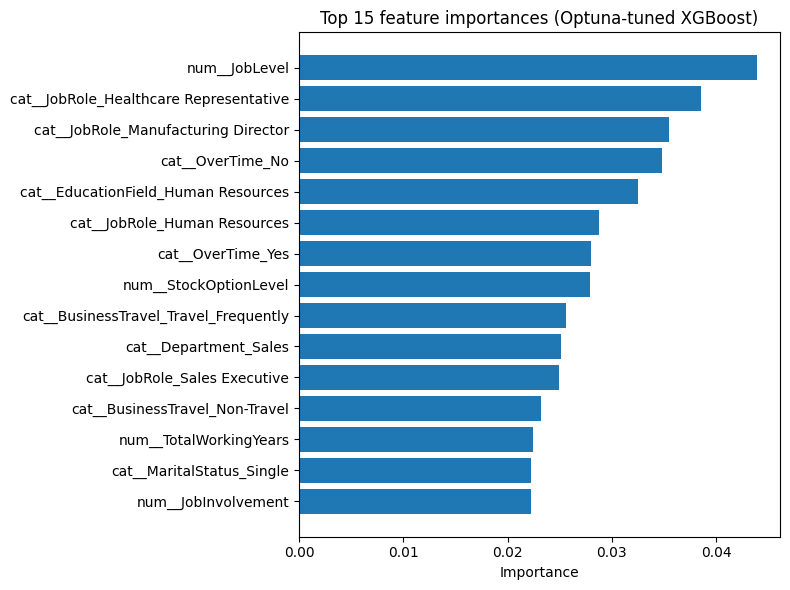

In [67]:
import matplotlib.pyplot as plt

top_n = 15
top_features = feat_imp.head(top_n).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Importance")
plt.title("Top 15 feature importances (Optuna-tuned XGBoost)")
plt.tight_layout()
plt.show()


You will often see overtime, income, age, tenure, job level, travel, or role show up. That supports a narrative about **risk factors the model learned**, not proof that any single field **makes** people quit.


## 6. SHAP (TreeExplainer)

Install if needed: `pip install shap`.

SHAP summarizes how each feature pushes the model output up or down. For a pipeline, transform `X_train` / `X_test` with the **same** fitted preprocessor, then explain the tree model on dense numeric arrays (sparse matrices are converted below).


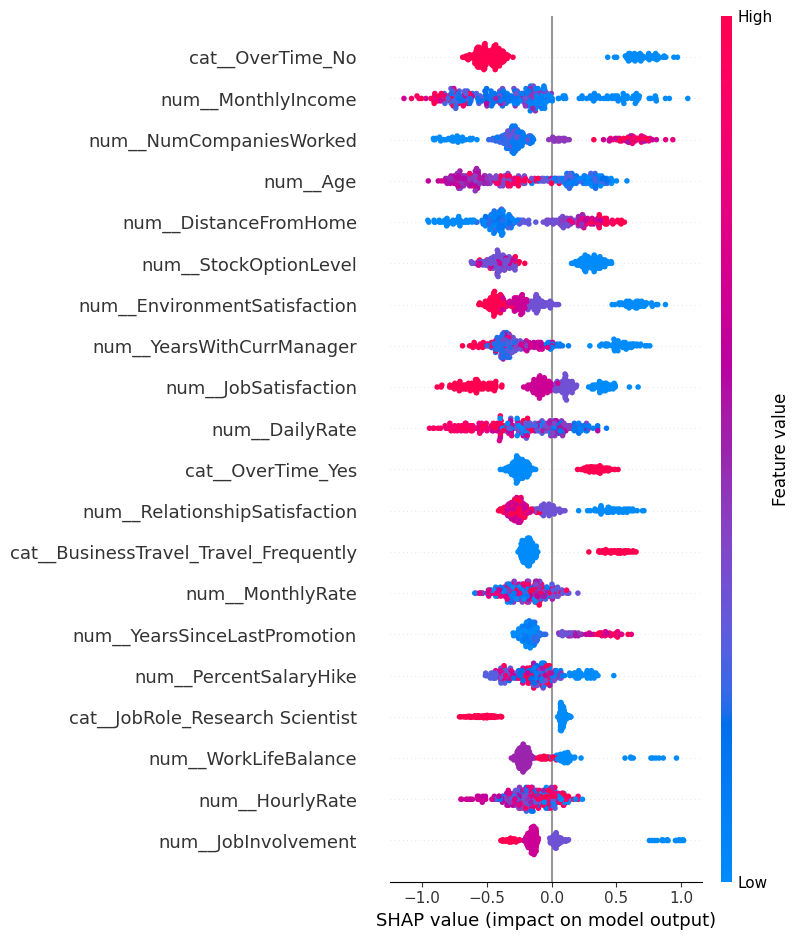

In [68]:
import shap
from scipy.sparse import issparse

prep = best_xgb_pipeline.named_steps["preprocessor"]
X_train_transformed = prep.transform(X_train)
X_test_transformed = prep.transform(X_test)

if issparse(X_train_transformed):
    X_train_transformed = X_train_transformed.toarray()
if issparse(X_test_transformed):
    X_test_transformed = X_test_transformed.toarray()

explainer = shap.TreeExplainer(best_xgb_pipeline.named_steps["model"])
shap_values = explainer.shap_values(X_test_transformed)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap.summary_plot(
    shap_values, X_test_transformed, feature_names=feature_names, show=True
)


## 7. How to phrase interpretation

**Avoid:** "OverTime *causes* attrition" or "Low income *causes* people to leave."

**Better:** "The model associated overtime, compensation-related inputs, and tenure or role features with **higher predicted attrition risk**." "SHAP suggested those inputs had among the largest effects on risk scores."

That keeps the story honest: you built a **predictive** model, not a randomized experiment.


## 8. Save final model pipeline and threshold

Persist the **full** fitted pipeline (preprocessor + XGBoost) so inference reloads the same transforms. Save the **tuned decision threshold** next to it (from Optuna XGBoost threshold search, e.g. **0.35** in our runs).

Run this **after** `best_xgb_pipeline` / `xgb_opt_pipeline` and `best_threshold_xgb_opt` exist.


In [69]:
from pathlib import Path
import joblib

models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

pipeline_path = models_dir / "final_xgb_pipeline.joblib"
threshold_path = models_dir / "final_threshold.joblib"

joblib.dump(best_xgb_pipeline, pipeline_path)

threshold_bundle = {
    "threshold": float(best_threshold_xgb_opt),
    "model_name": "optuna_xgboost",
    "positive_class_label": "attrition",
}
joblib.dump(threshold_bundle, threshold_path)

print("Saved:", pipeline_path.resolve())
print("Saved:", threshold_path.resolve())
print("Threshold:", threshold_bundle["threshold"])


Saved: C:\Users\HP\employee_attrition\employee-attrition-ml\models\final_xgb_pipeline.joblib
Saved: C:\Users\HP\employee_attrition\employee-attrition-ml\models\final_threshold.joblib
Threshold: 0.3500000000000001


## 9. Batch prediction from disk

For CLI or API use, see `src/predict.py` (load artifacts, build a one-row `DataFrame` with the **same** columns as training `X`, then `predict_proba` and apply the saved threshold). `app/main.py` exposes **FastAPI** `GET /health` and `POST /predict` once artifacts exist.
